# Introducción a Magpylib: modelos simples de una bobina

Este notebook está pensado para alumnos del **Laboratorio de Electricidad y Magnetismo**. El objetivo es aprender a usar **Magpylib** en problemas sencillos de magnetostática.

La idea principal será construir una **bobina** de dos maneras:

1. con un modelo **simplificado**, usando una colección de espiras circulares,
2. con un modelo **más preciso**, representando el conductor como una espira helicoidal.

Al final se agrega un ejemplo adicional con un **imán cilíndrico**, para que puedan explorarlo por su cuenta.

## Antes de empezar: unidades y cambios de API

En **Magpylib 5** conviene trabajar en **unidades SI**:

- longitud en **m**
- corriente en **A**
- campo magnético en **T**

En este notebook vamos a calcular siempre en SI, pero en muchos gráficos mostraremos resultados en **mm** o **mT** para que sean más cómodos de leer.

Además, respecto de materiales más viejos:

- `magpy.current.Loop` pasó a representarse con `magpy.current.Circle`,
- `magpy.current.Line` pasó a `magpy.current.Polyline`,
- para imanes se usa `polarization` en lugar de `magnetization` en este tipo de ejemplo introductorio.

In [1]:
import importlib
import subprocess
import sys

paquetes = ['magpylib', 'numpy', 'matplotlib', 'pandas']
faltantes = []
for paquete in paquetes:
    try:
        importlib.import_module(paquete)
    except ImportError:
        faltantes.append(paquete)

if faltantes:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *faltantes])
    print('Se instalaron:', ', '.join(faltantes))
else:
    print('Dependencias listas.')

Dependencias listas.


In [2]:
import magpylib as magpy
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.style.use('seaborn-v0_8-whitegrid')
print('Magpylib versión:', magpy.__version__)

Magpylib versión: 5.2.3


## 1. Modelo simplificado de una bobina con `Collection`

Para hacer el modelo de una bobina, vamos a aprovechar la clase **`Collection`** que posee Magpylib para juntar varias fuentes de corriente en una sola por superposición.

La idea es representar la bobina como una colección de **espiras circulares** idénticas, separadas regularmente a lo largo del eje `z`.

Objeto creado: Collection(id=2074529493840)
Cantidad de espiras: 16
Primera espira: Circle(id=2074529496912)


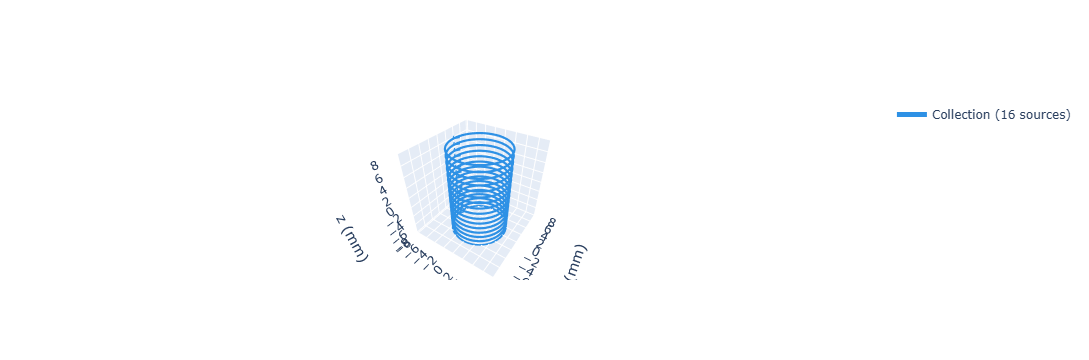

In [3]:
corriente = 10.0   # A
diametro = 0.010  # m
largo = 0.016     # m
n_espiras = 16

bobina_simple = magpy.Collection()

for z in np.linspace(-largo/2, largo/2, n_espiras):
    espira = magpy.current.Circle(
        current=corriente,
        diameter=diametro,
        position=(0, 0, z),
    )
    bobina_simple.add(espira)

print('Objeto creado:', bobina_simple)
print('Cantidad de espiras:', len(bobina_simple.children))
print('Primera espira:', bobina_simple.children[0])

bobina_simple.show()

## 2. Modelo más preciso de la misma bobina

Ahora representamos el conductor como una **hélice**. Este modelo puede ser más realista, pero también es **más costoso computacionalmente** y, si no se discretiza bien, puede introducir errores numéricos.

En lugar de crear muchas espiras separadas, definimos una curva 3D mediante una lista de vértices.

> **Importante:** el campo de un hilo ideal diverge si se evalúa exactamente **sobre el conductor**. En algunas interfaces gráficas eso puede volver inestable la visualización. Por eso, en la sección siguiente vamos a mirar un plano apenas corrido respecto de `y=0`.

Objeto creado: Polyline(id=2074552936400)
Cantidad de vértices usados: 1200


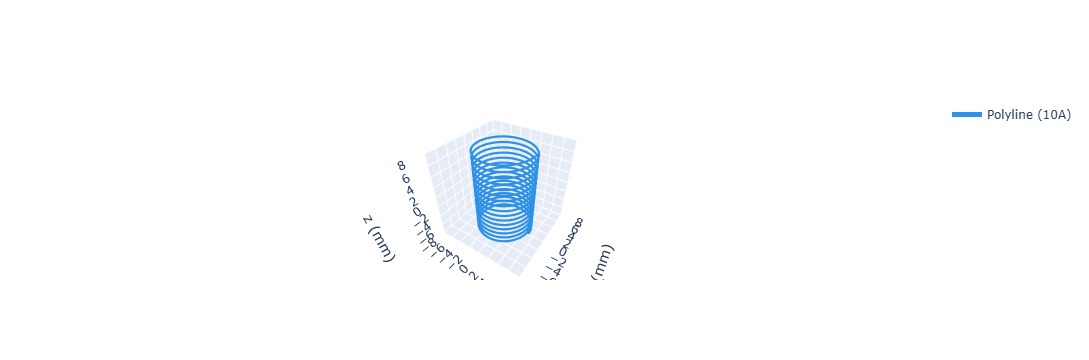

In [4]:
t = np.linspace(0, n_espiras*2*np.pi, 1200)
radio = diametro/2
z_helice = np.linspace(-largo/2, largo/2, t.size)

vertices = np.c_[
    radio*np.cos(t),
    radio*np.sin(t),
    z_helice,
]

bobina_helicoidal = magpy.current.Polyline(
    current=corriente,
    vertices=vertices,
)

print('Objeto creado:', bobina_helicoidal)
print('Cantidad de vértices usados:', len(vertices))
bobina_helicoidal.show()

## 3. Campo sobre el eje de la bobina

Una forma muy útil de analizar el problema es calcular el campo sobre el eje `z`, es decir en puntos de la forma `(0, 0, z)`.

Eso nos permite comparar cuantitativamente ambos modelos.

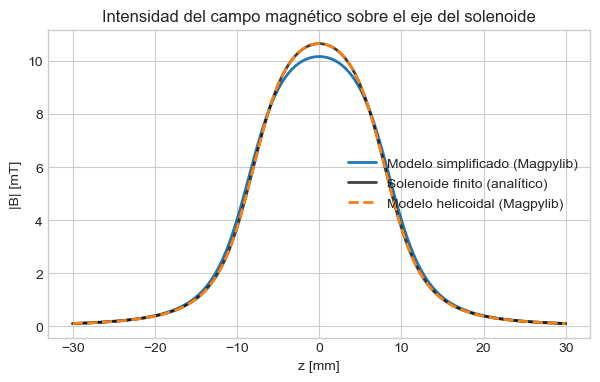

,z [mm],|B| simple (Magpylib) [mT],|B| analítico [mT],|B| helicoidal (Magpylib) [mT]
0,-8.0,6.266838,5.997175,5.997525
1,0.0,10.168379,10.656261,10.658441
2,4.0,9.435119,9.724938,9.727398
3,8.0,6.266838,5.997175,5.997525


In [5]:
# Función para la solución analítica de un solenoide FINITO (modelo continuo)
# Para un solenoide ideal de radio R y longitud L, con densidad de espiras n = N/L,
# el campo sobre el eje (0,0,z), tomando el solenoide centrado en z=0, es:
#
# Bz(z) = (mu0*n*I/2) * [ (z+L/2)/sqrt(R^2+(z+L/2)^2) - (z-L/2)/sqrt(R^2+(z-L/2)^2) ]

def Bz_solenoide_analitico(z, corriente, diametro, largo, n_espiras):
    '''Campo Bz (en Tesla) sobre el eje de un solenoide finito ideal (aprox. continua).

    Parámetros
    ----------
    z : float o array-like
        Coordenada(s) axial(es) (m) donde se evalúa el campo (sobre el eje).
    corriente : float
        Corriente (A).
    diametro : float
        Diámetro del solenoide (m).
    largo : float
        Longitud del solenoide (m).
    n_espiras : int
        Número total de espiras N.

    Retorna
    -------
    Bz : ndarray
        Componente axial del campo (T). Si z es escalar, retorna un array de 1 elemento.
    '''
    mu0 = 4*np.pi*1e-7
    z = np.atleast_1d(z).astype(float)

    R = diametro/2
    L = float(largo)
    n = n_espiras / L  # densidad de espiras (1/m)

    z1 = z + L/2
    z2 = z - L/2

    Bz = 0.5 * mu0 * n * corriente * (
        z1/np.sqrt(R**2 + z1**2) - z2/np.sqrt(R**2 + z2**2)
    )

    return Bz


# --- Gráfico: intensidad del campo sobre el eje ---
z_eje = np.linspace(-0.03, 0.03, 200)
puntos_eje = np.c_[np.zeros_like(z_eje), np.zeros_like(z_eje), z_eje]

# Pedimos el campo SOLO sobre el eje (no en un plano completo)
B_simple = magpy.getB(bobina_simple, puntos_eje)
B_helice = magpy.getB(bobina_helicoidal, puntos_eje)

Bamp_simple = np.linalg.norm(B_simple, axis=1)
Bamp_helice = np.linalg.norm(B_helice, axis=1)

Bz_anal = Bz_solenoide_analitico(z_eje, corriente, diametro, largo, n_espiras)
Bamp_anal = np.abs(Bz_anal)  # en el modelo analítico el campo es axial

plt.figure(figsize=(7, 4))
plt.plot(z_eje*1000, Bamp_simple*1000, label='Modelo simplificado (Magpylib)', lw=2)
plt.plot(z_eje*1000, Bamp_anal*1000, label='Solenoide finito (analítico)', lw=2, color='k', alpha=0.75)
plt.plot(z_eje*1000, Bamp_helice*1000, label='Modelo helicoidal (Magpylib)', lw=2, ls='--')
plt.xlabel('z [mm]')
plt.ylabel('|B| [mT]')
plt.title('Intensidad del campo magnético sobre el eje del solenoide')
plt.legend()
plt.show()


# --- Tabla: comparación en extremos, centro y un punto intermedio ---
z_eval = np.array([-largo/2, 0.0, largo/4, largo/2])
puntos_eval = np.c_[np.zeros_like(z_eval), np.zeros_like(z_eval), z_eval]

# Pedimos el campo SOLO sobre el eje (no en un plano completo)
B_simple_eval = magpy.getB(bobina_simple, puntos_eval)
B_helice_eval = magpy.getB(bobina_helicoidal, puntos_eval)

Bamp_simple_eval = np.linalg.norm(B_simple_eval, axis=1)
Bamp_helice_eval = np.linalg.norm(B_helice_eval, axis=1)
Bamp_anal_eval = np.abs(Bz_solenoide_analitico(z_eval, corriente, diametro, largo, n_espiras))

tabla = pd.DataFrame({
    'z [mm]': z_eval*1000,
    '|B| simple (Magpylib) [mT]': Bamp_simple_eval*1000,
    '|B| analítico [mT]': Bamp_anal_eval*1000,
    '|B| helicoidal (Magpylib) [mT]': Bamp_helice_eval*1000,
})

tabla


## 4. Visualización del campo en el plano `xz`

Vamos a comparar ambos modelos calculando el campo magnético en una grilla del plano `xz`.

Para evitar puntos exactamente sobre el conductor de la hélice, tomamos un plano con **`y = 1 mm`** en lugar de `y = 0`.

En ambos paneles usamos ahora la **misma visualización**: un mapa de color de la intensidad relativa del campo y, encima, líneas de flujo. Así la comparación entre los dos modelos es más directa.

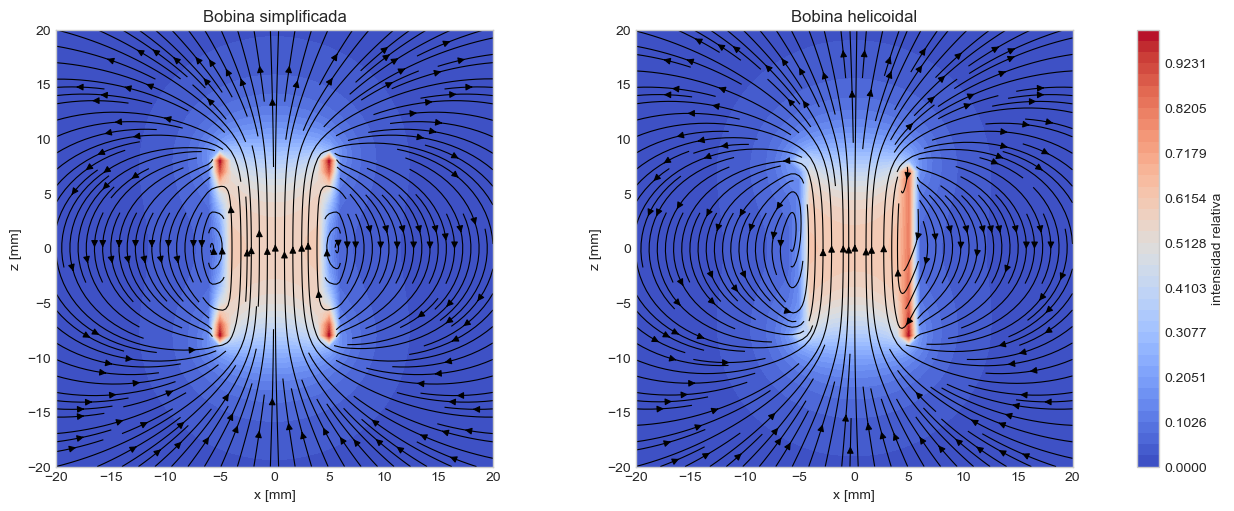

In [6]:
y_plano = 0.001  # m = 1 mm; evita evaluar exactamente sobre el hilo helicoidal

xs = np.linspace(-0.02, 0.02, 41)
zs = np.linspace(-0.02, 0.02, 41)
grid = np.array([[(x, y_plano, z) for x in xs] for z in zs])

B_simple = magpy.getB(bobina_simple, grid)
B_helice = magpy.getB(bobina_helicoidal, grid)

Bamp_simple = np.linalg.norm(B_simple, axis=2)
Bamp_helice = np.linalg.norm(B_helice, axis=2)

Bamp_simple_norm = Bamp_simple / Bamp_simple.max()
Bamp_helice_norm = Bamp_helice / Bamp_helice.max()

X_mm = grid[:, :, 0] * 1000
Z_mm = grid[:, :, 2] * 1000
niveles = np.linspace(0, 1, 40)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)

cf1 = ax1.contourf(
    X_mm, Z_mm, Bamp_simple_norm,
    levels=niveles,
    cmap='coolwarm',
)
ax1.streamplot(
    X_mm, Z_mm,
    B_simple[:, :, 0], B_simple[:, :, 2],
    density=1.8,
    color='black',
    linewidth=0.8,
)

cf2 = ax2.contourf(
    X_mm, Z_mm, Bamp_helice_norm,
    levels=niveles,
    cmap='coolwarm',
)
ax2.streamplot(
    X_mm, Z_mm,
    B_helice[:, :, 0], B_helice[:, :, 2],
    density=1.8,
    color='black',
    linewidth=0.8,
)

ax1.set(title='Bobina simplificada', xlabel='x [mm]', ylabel='z [mm]', aspect=1)
ax2.set(title='Bobina helicoidal', xlabel='x [mm]', ylabel='z [mm]', aspect=1)

fig.colorbar(cf2, ax=[ax1, ax2], label='intensidad relativa')
plt.show()


## 5. Actividades sugeridas

1. Cambien el valor de la **corriente**. ¿Cómo cambia el campo?
2. Modifiquen el número de **espiras** manteniendo fijo el largo. ¿Qué ocurre en la región central?
3. Cambien el **diámetro** de la bobina y comparen nuevamente ambos modelos.
4. Aumenten o disminuyan la cantidad de **vértices** de la hélice. ¿Qué pasa con el tiempo de cálculo y con la suavidad de los resultados?
5. Midan el campo fuera del eje, por ejemplo en puntos `(x,0,z)` con `x != 0`.

## 6. Ejemplo adicional: un imán cilíndrico

Este ejemplo queda como material extra para explorar en casa. Vamos a construir un imán cilíndrico uniformemente polarizado a lo largo del eje `z` y mirar su campo.

In [7]:
iman = magpy.magnet.Cylinder(
    polarization=(0, 0, 1.2),
    dimension=(0.015, 0.005),   # diámetro, altura [m]
)

print('Objeto creado:', iman)
print('Polarización [T]:', iman.polarization)
print('Dimensiones [m]:', iman.dimension)
print('Posición [m]:', iman.position)

Objeto creado: Cylinder(id=2074557992528)
Polarización [T]: [0.  0.  1.2]
Dimensiones [m]: [0.015 0.005]
Posición [m]: [0. 0. 0.]


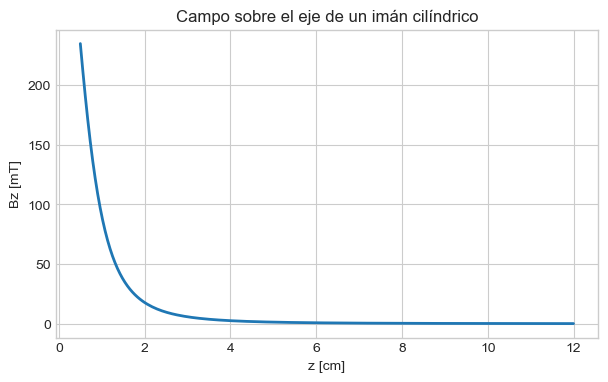

In [8]:
z_iman = np.linspace(0.005, 0.12, 200)
puntos_iman = np.c_[np.zeros_like(z_iman), np.zeros_like(z_iman), z_iman]
B_iman = magpy.getB(iman, puntos_iman)

plt.figure(figsize=(7,4))
plt.plot(z_iman*100, B_iman[:, 2]*1000, lw=2)
plt.xlabel('z [cm]')
plt.ylabel('Bz [mT]')
plt.title('Campo sobre el eje de un imán cilíndrico')
plt.show()

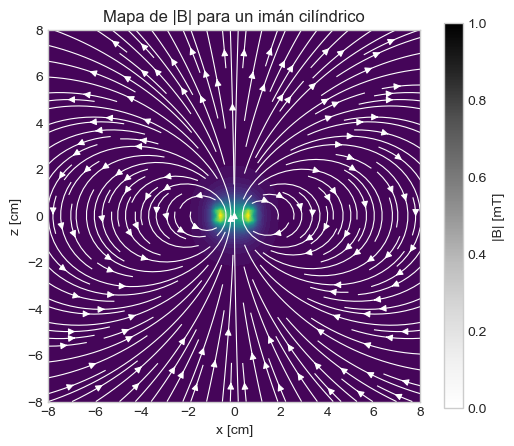

In [9]:
xs = np.linspace(-0.08, 0.08, 81)
zs = np.linspace(-0.08, 0.08, 81)
grid_iman = np.array([[(x, 0, z) for x in xs] for z in zs])
B_iman_grid = magpy.getB(iman, grid_iman)
B_iman_mod = np.linalg.norm(B_iman_grid, axis=2)

X_cm = grid_iman[:, :, 0] * 100
Z_cm = grid_iman[:, :, 2] * 100

plt.figure(figsize=(6, 5))
plt.contourf(X_cm, Z_cm, B_iman_mod*1000, levels=40, cmap='viridis')
plt.streamplot(X_cm, Z_cm, B_iman_grid[:, :, 0], B_iman_grid[:, :, 2], color='white', density=1.6, linewidth=0.8)
plt.xlabel('x [cm]')
plt.ylabel('z [cm]')
plt.title('Mapa de |B| para un imán cilíndrico')
plt.colorbar(label='|B| [mT]')
plt.gca().set_aspect('equal')
plt.show()

## Para seguir

Este notebook puede tomarse como punto de partida para:

- comparar simulaciones con datos experimentales,
- estudiar otras geometrías,
- analizar perfiles sobre distintos ejes,
- discutir qué tan bueno es un modelo simplificado frente a uno más detallado.